# 02 Dimensions Analysis


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from numpy import linalg as la

from config import PROCESSED_DATAFRAMES_DIR


SV_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_data.pkl"

df_sv = pd.read_pickle(SV_DATAFRAME_PATH)

df_sv.head()


,molecule,active_space,ansatz,expansion,H,S,qse_dim,S2,pyscf_casci_energies,pyscf_casci_pvec
0,Acetamide,2e2o,1UpCCGSDSinglet,singlet,"[[(-802.5663414572622+0j), (-4.706692634862638...","[[(3.9097041888243123+0j), (0.0229245233142809...",4,"[[(1.27675647831893e-14+0j), (-4.3368086899420...","[-205.29449911826808, -204.8258180441668, -204...","{'0': [-0.15005494805049122, 0, -0.00628487098..."
1,Acetamide,2e2o,1UpCCGSDSinglet,triplet_all,"[[(-0.008069881124952466+0j), 0j, 0j, (0.19302...","[[(3.9350963402490224e-05+0j), 0j, 0j, (-0.000...",12,"[[(7.870192680212162e-05+0j), 0j, 0j, (-0.0018...",[-205.07455054622508],"{'0_0': [-4.001328838134542e-16, 0, -0.7071067..."
2,Acetamide,2e2o,UCCGSD,singlet,"[[(-802.5658955566977+0j), (-4.714686911530125...","[[(3.909702017207626+0j), (0.02296346038353209...",4,"[[(1.2961853812498703e-14+0j), (-4.33680868994...","[-205.29449911826808, -204.8258180441668, -204...","{'0': [-0.15005494805049122, 0, -0.00628487098..."
3,Acetamide,2e2o,UCCGSD,triplet_all,"[[(-0.008097333197893943+0j), 0j, 0j, (0.19335...","[[(3.9484827272451284e-05+0j), 0j, 0j, (-0.000...",12,"[[(7.896965454190497e-05+0j), 0j, 0j, (-0.0018...",[-205.07455054622508],"{'0_0': [-4.001328838134542e-16, 0, -0.7071067..."
4,Acetamide,2e2o,UCCSD,singlet,"[[(-802.5658955566977+0j), (-4.714686911530125...","[[(3.909702017207626+0j), (0.02296346038353209...",4,"[[(1.2961853812498703e-14+0j), (-4.33680868994...","[-205.29449911826808, -204.8258180441668, -204...","{'0': [-0.15005494805049122, 0, -0.00628487098..."


## 1. Overlap Eigenvalue Edge Cases

Compare representative small and larger active spaces side by side, such as `2e3o` and `4e4o`, to show how the overlap-matrix spectrum changes with QSE dimension. The goal is to make the tiny-eigenvalue problem visible before applying any filtering or stabilization.



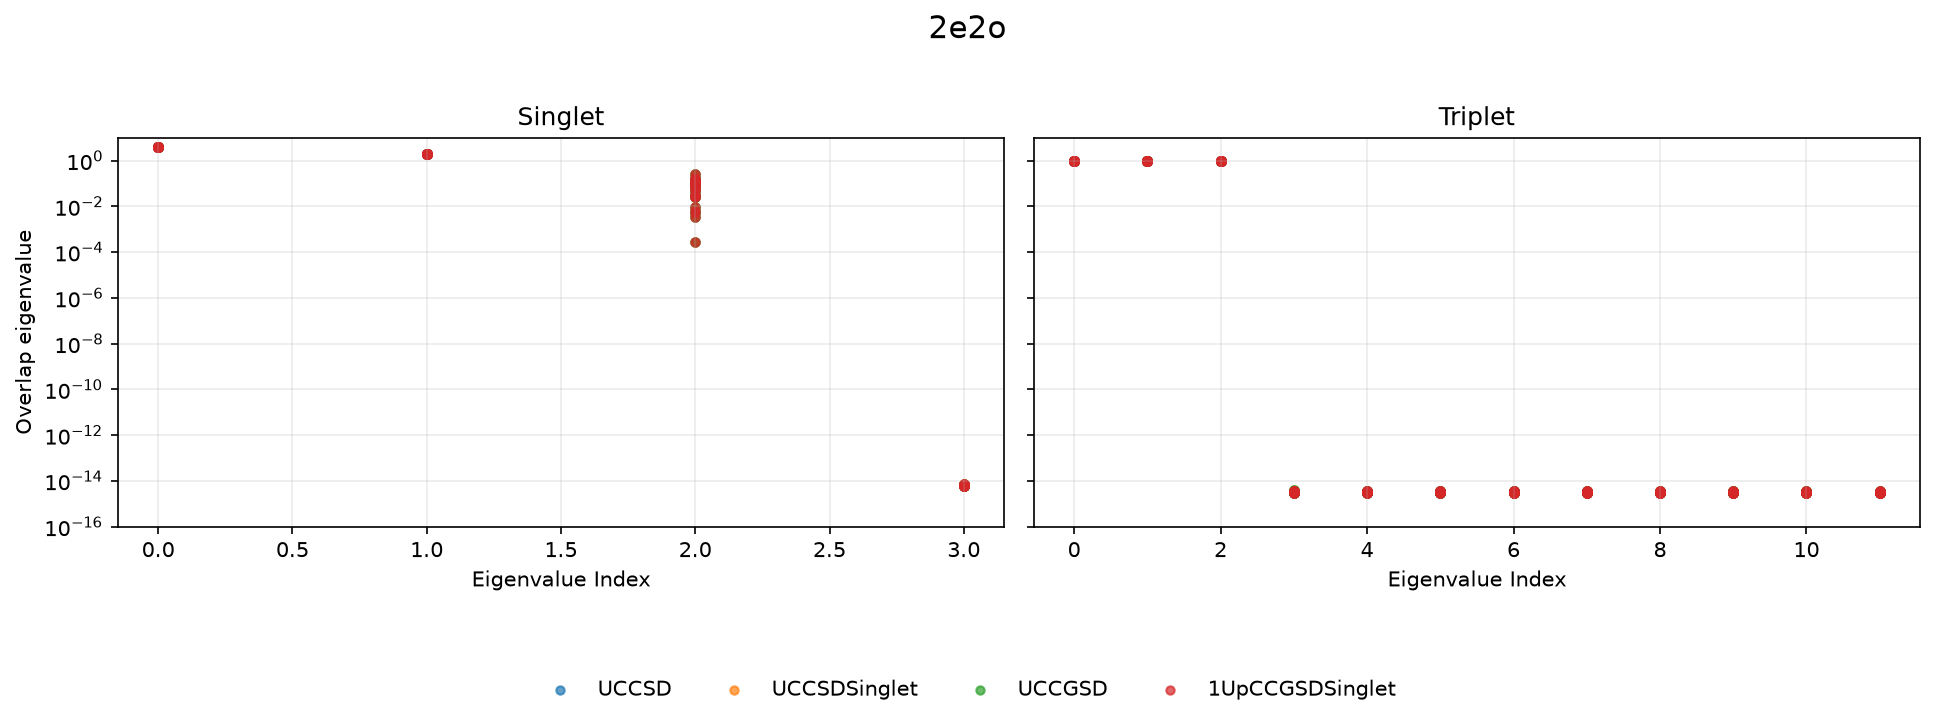
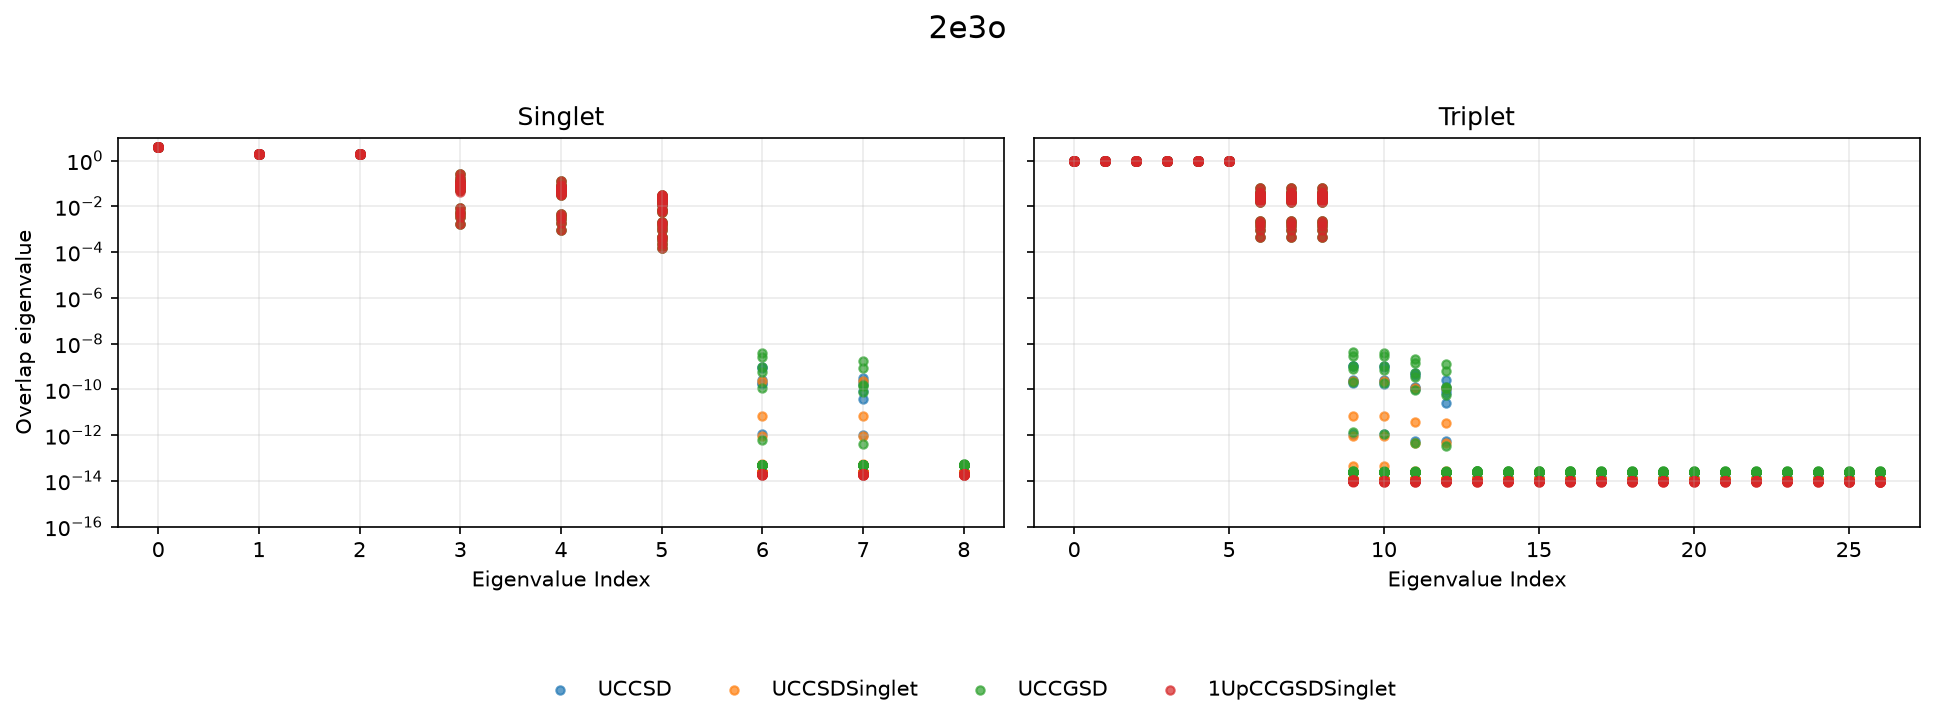
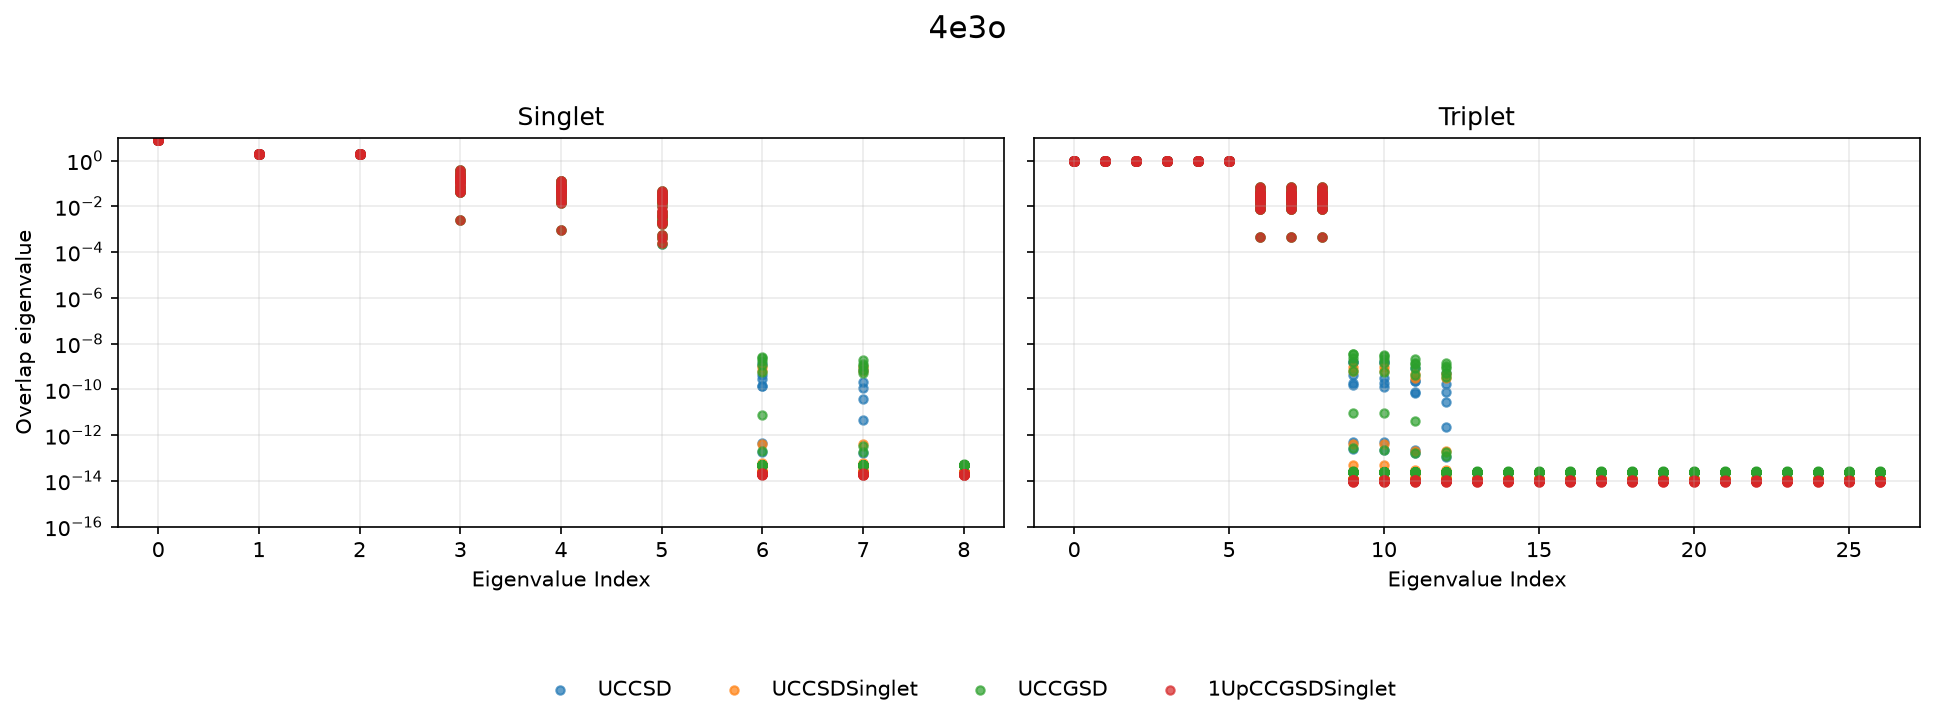
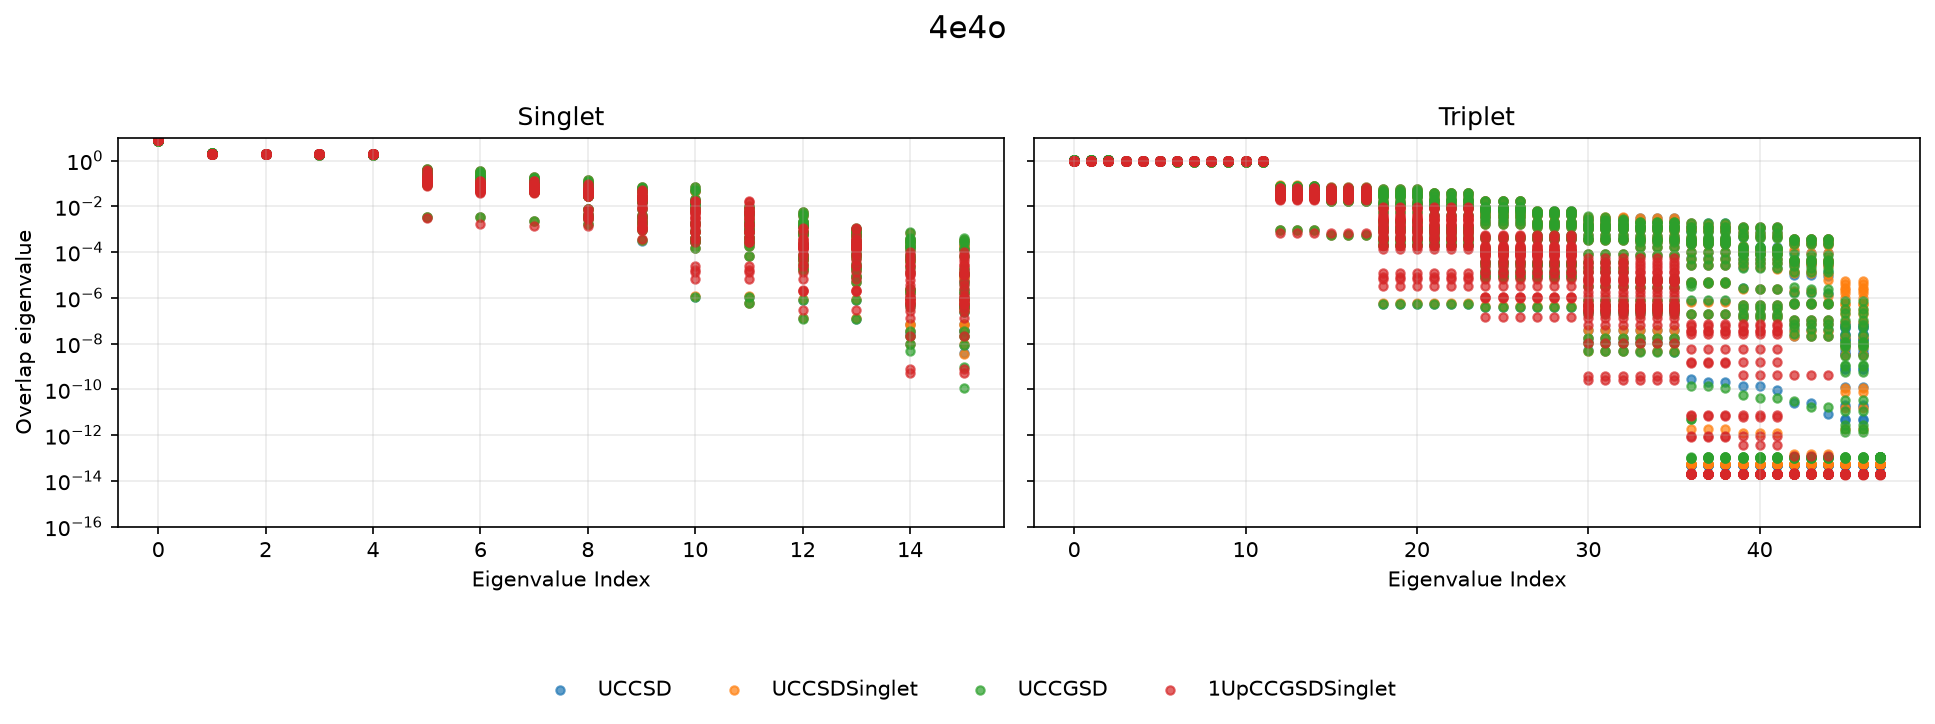
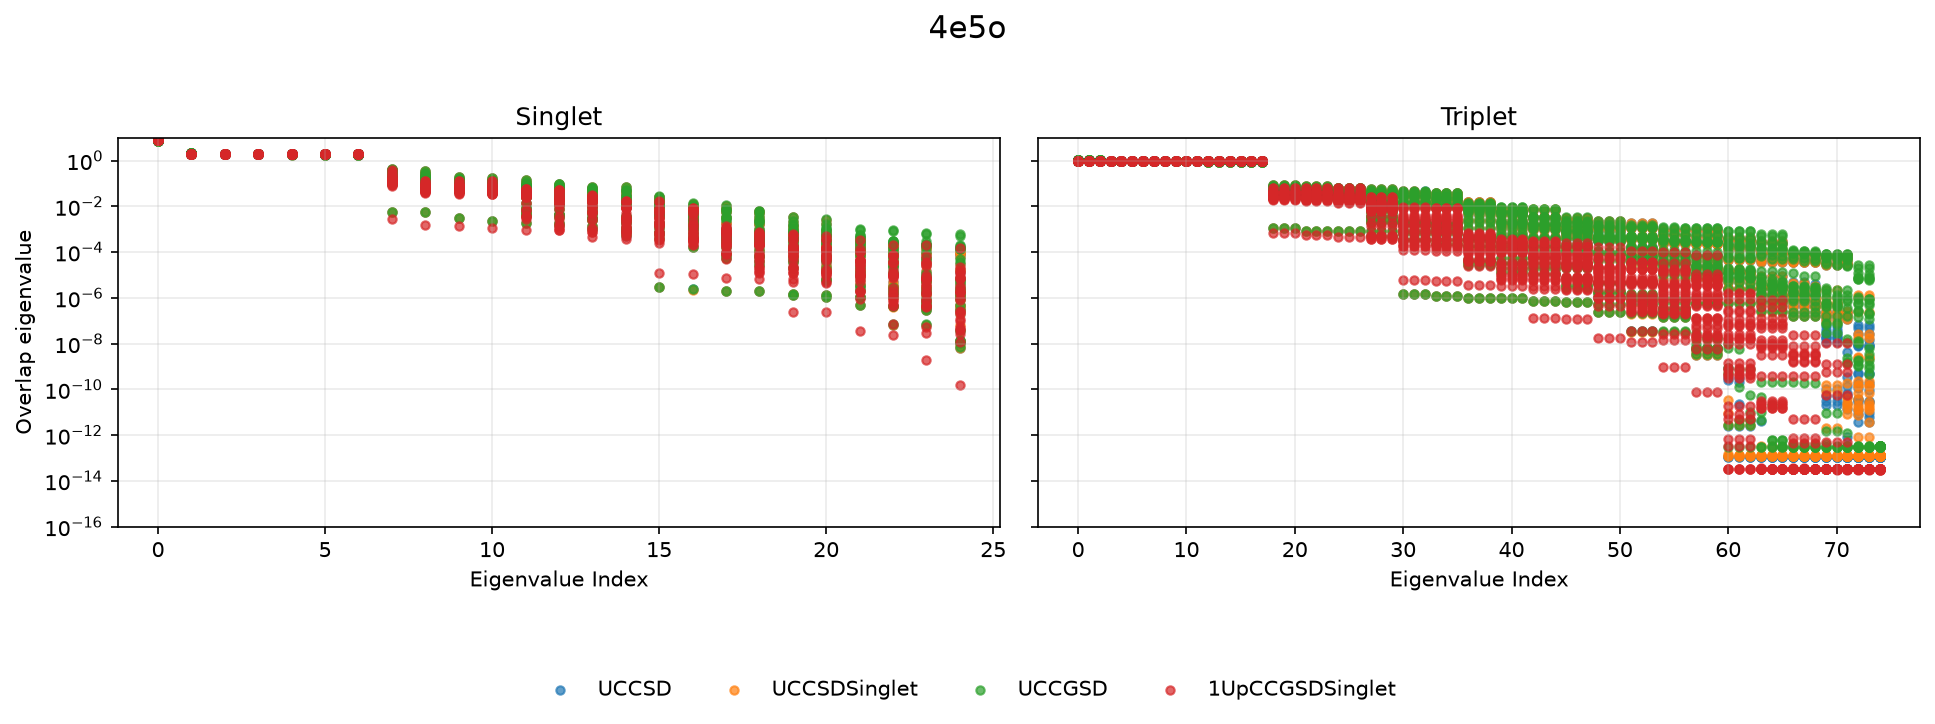
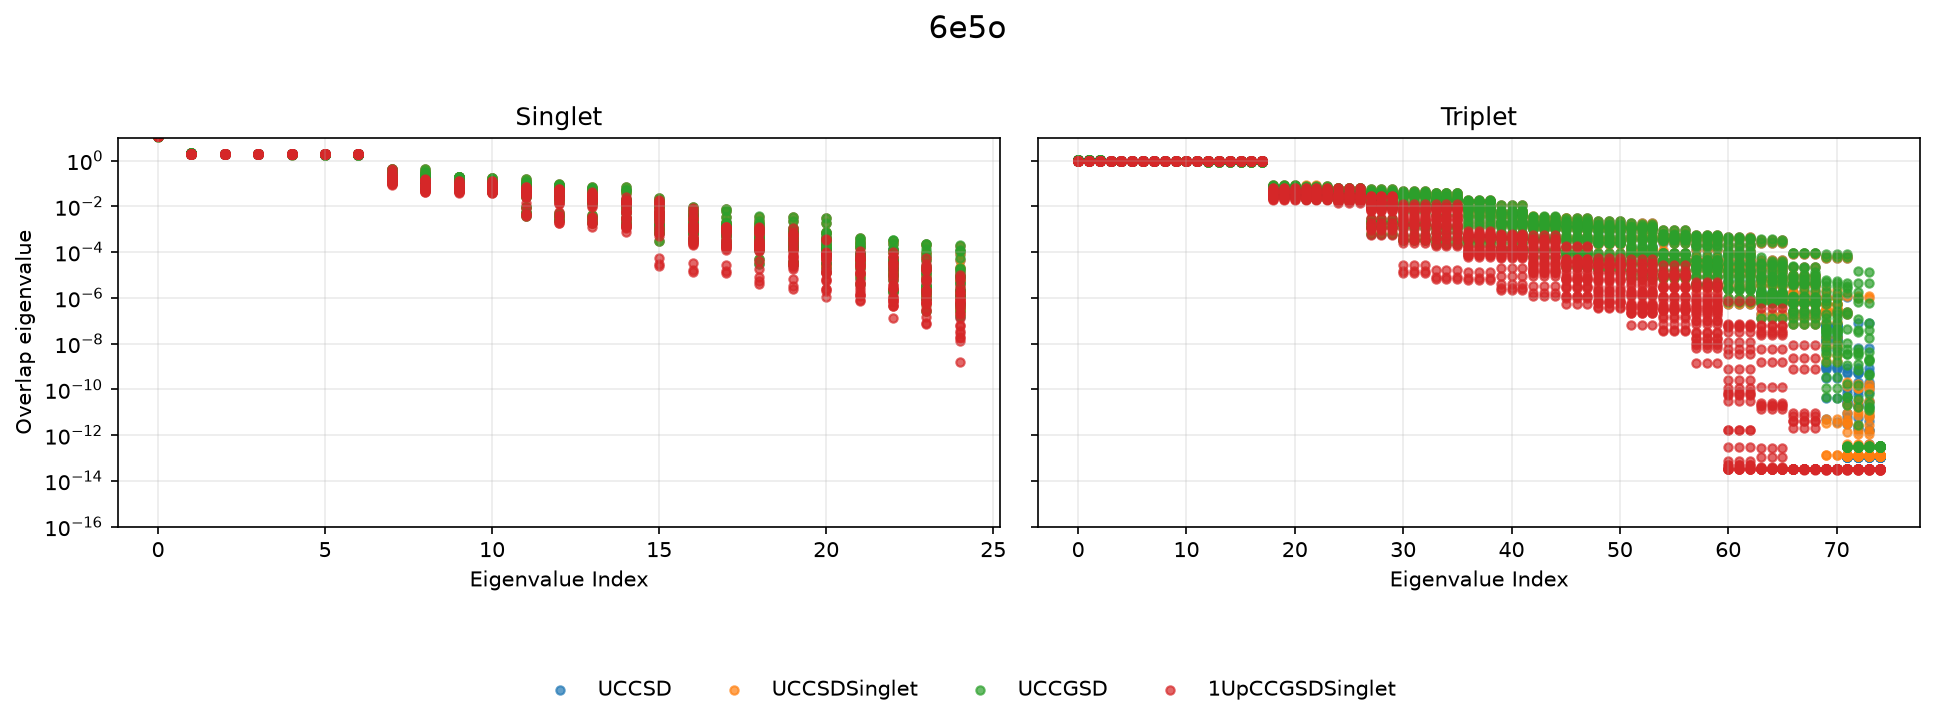
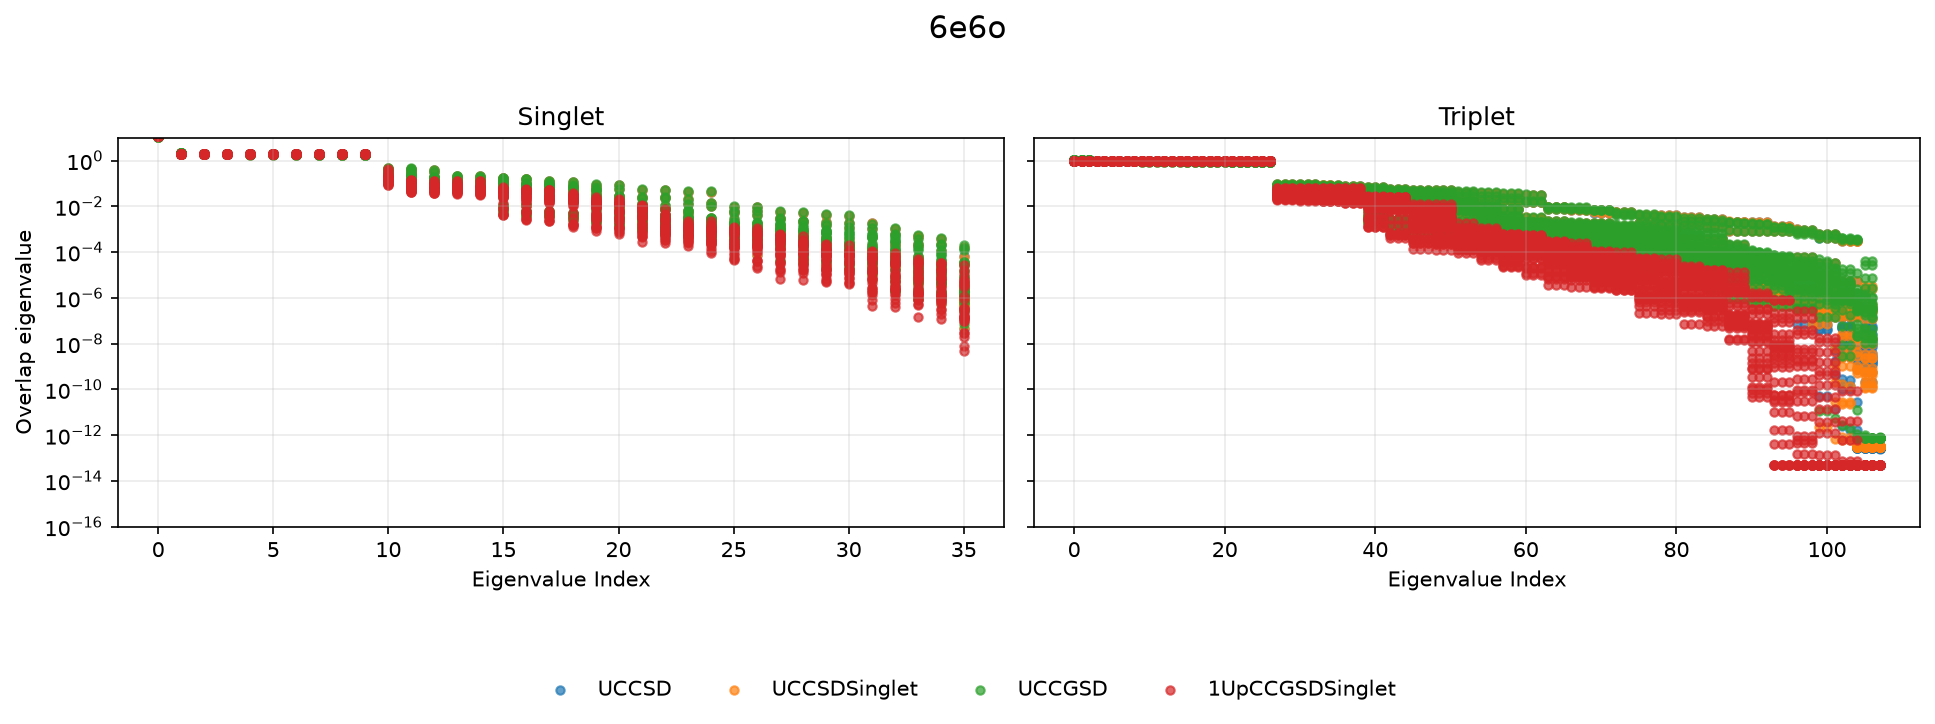

In [2]:
from notebook_utils.graphs import (
    ANSATZ_ORDER, EIGENVECTOR_COMPOSITION_GROUPS, plot_eigenvector_composition_bars,
    plot_spin_eigenvalue_spread, show_scrollable_figs,
)


def overlap_eigenvalue_dict(df, active_space, expansion):
    data = {ansatz: [] for ansatz in ANSATZ_ORDER}
    rows = df[
        (df["active_space"] == active_space)
        & (df["expansion"] == expansion)
    ].copy()
    rows["ansatz"] = pd.Categorical(rows["ansatz"], categories=ANSATZ_ORDER, ordered=True)
    rows = rows.sort_values(["ansatz", "molecule"])

    for _, row in rows.iterrows():
        eigenvalues = np.sort(la.eigvalsh(np.asarray(row["S"], dtype=complex)).real)[::-1]
        points = [(index, eigenvalue) for index, eigenvalue in enumerate(eigenvalues)]

        data.setdefault(str(row["ansatz"]), []).extend(points)

    return {ansatz: points for ansatz, points in data.items() if points}


active_spaces = df_sv["active_space"].drop_duplicates().tolist()
eigenvalue_spreads = {}
figs = []

for active_space in active_spaces:
    singlet_data = overlap_eigenvalue_dict(df_sv, active_space, "singlet")
    triplet_data = overlap_eigenvalue_dict(df_sv, active_space, "triplet_all")

    eigenvalue_spreads[active_space] = {
        "singlet": singlet_data,
        "triplet": triplet_data,
    }

    fig, axes = plot_spin_eigenvalue_spread(
        singlet_data,
        triplet_data,
        title=active_space,
    )
    figs.append(fig)

show_scrollable_figs(figs)


## 2. Eigenvector Composition

For each active space, diagonalize the UCCSD singlet and triplet statevector overlap matrices and order their eigenvectors by decreasing eigenvalue. Each visualization shows the mean composition across 28 molecules using three groups: occupied-orbital number operators, `OV`, and `Rest = virtual Number + VO + OO + VV`.


In [3]:
from notebook_utils.operators import get_dimension_operator_labels, get_qse_operators


operator_group_labels = {}
for active_space in active_spaces:
    singlet_operators, triplet_operators = get_qse_operators(active_space)
    operator_group_labels[active_space] = {
        "singlet": get_dimension_operator_labels(singlet_operators, active_space),
        "triplet": get_dimension_operator_labels(triplet_operators, active_space),
    }


def overlap_eigenvector_composition(S, labels):
    """Return grouped weights in decreasing overlap-eigenvalue order."""
    _, eigenvectors = np.linalg.eigh(np.asarray(S, dtype=complex))
    component_weights = 100.0 * np.abs(eigenvectors[:, ::-1]) ** 2
    labels = np.asarray(labels)
    return {
        group: component_weights[labels == group].sum(axis=0)
        for group in EIGENVECTOR_COMPOSITION_GROUPS
    }

In [4]:
df_uccsd = df_sv[df_sv["ansatz"] == "UCCSD"]
spin_expansions = {"singlet": "singlet", "triplet": "triplet_all"}
composition_results = {}
composition_validation = []

for active_space in active_spaces:
    composition_results[active_space] = {}

    for spin, expansion in spin_expansions.items():
        subset = df_uccsd[
            (df_uccsd["active_space"] == active_space) & (df_uccsd["expansion"] == expansion)
        ].sort_values("molecule")
        labels = operator_group_labels[active_space][spin]
        molecule_compositions = [overlap_eigenvector_composition(S, labels) for S in subset["S"]]
        mean_composition = {
            group: np.mean([composition[group] for composition in molecule_compositions], axis=0)
            for group in EIGENVECTOR_COMPOSITION_GROUPS
        }
        composition_results[active_space][spin] = mean_composition
        matrix_dimensions = sorted({S.shape[0] for S in subset["S"]})
        total_weight = sum(mean_composition.values())
        composition_validation.append({
            "active_space": active_space, "spin": spin, "molecules": len(subset),
            "matrix_dimensions": matrix_dimensions, "label_count": len(labels),
            "maximum_weight_error": np.max(np.abs(total_weight - 100)),
        })

In [5]:
df_composition_validation = pd.DataFrame(composition_validation)
df_composition_validation

,active_space,spin,molecules,matrix_dimensions,label_count,maximum_weight_error
0,2e2o,singlet,28,[4],4,2.842171e-14
1,2e2o,triplet,28,[12],12,4.263256e-14
2,2e3o,singlet,28,[9],9,2.842171e-14
3,2e3o,triplet,28,[27],27,4.263256e-14
4,4e3o,singlet,28,[9],9,2.842171e-14
5,4e3o,triplet,28,[27],27,2.842171e-14
6,4e4o,singlet,28,[16],16,4.263256e-14
7,4e4o,triplet,28,[48],48,4.263256e-14
8,4e5o,singlet,28,[25],25,4.263256e-14
9,4e5o,triplet,28,[75],75,5.684342e-14


Singlet/triplet 100%-stacked bar representation.



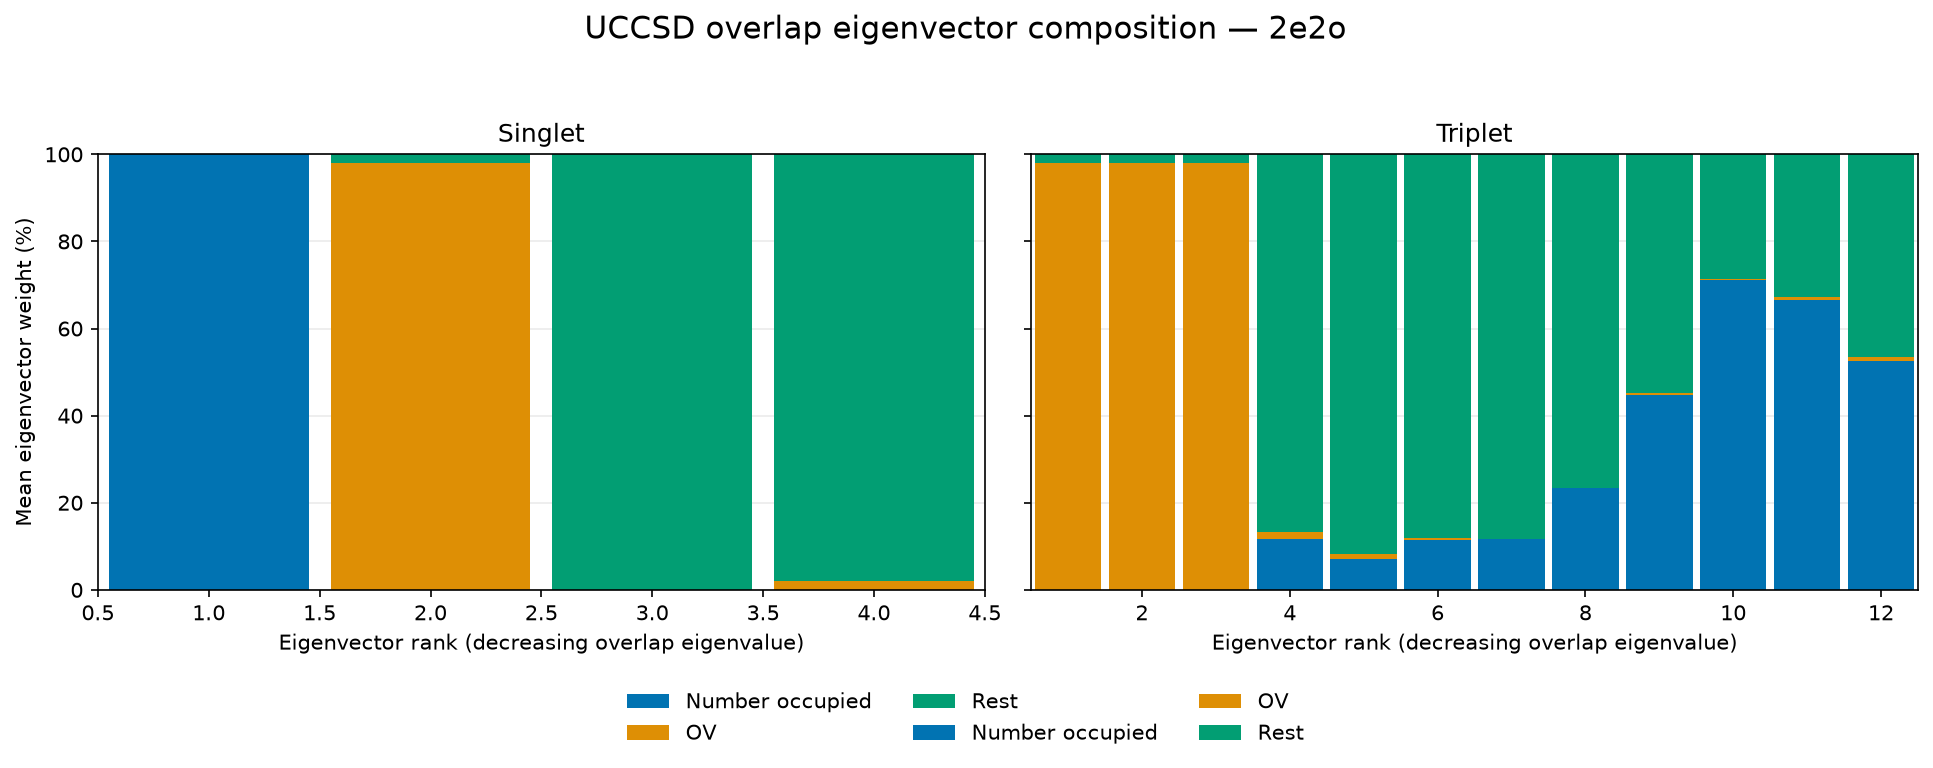
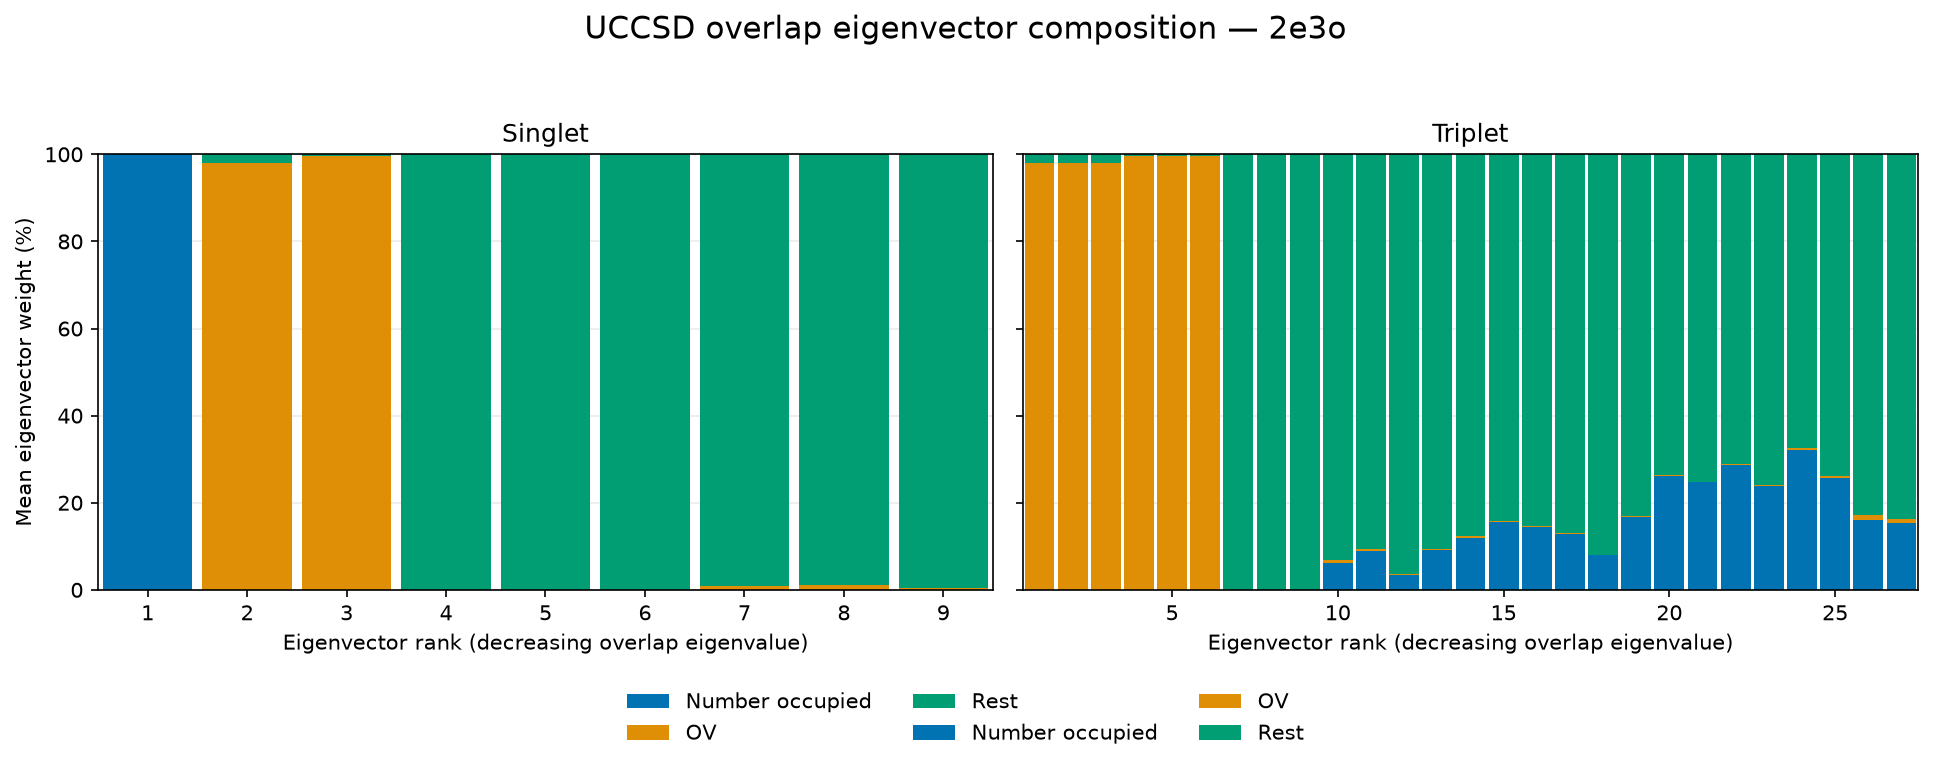
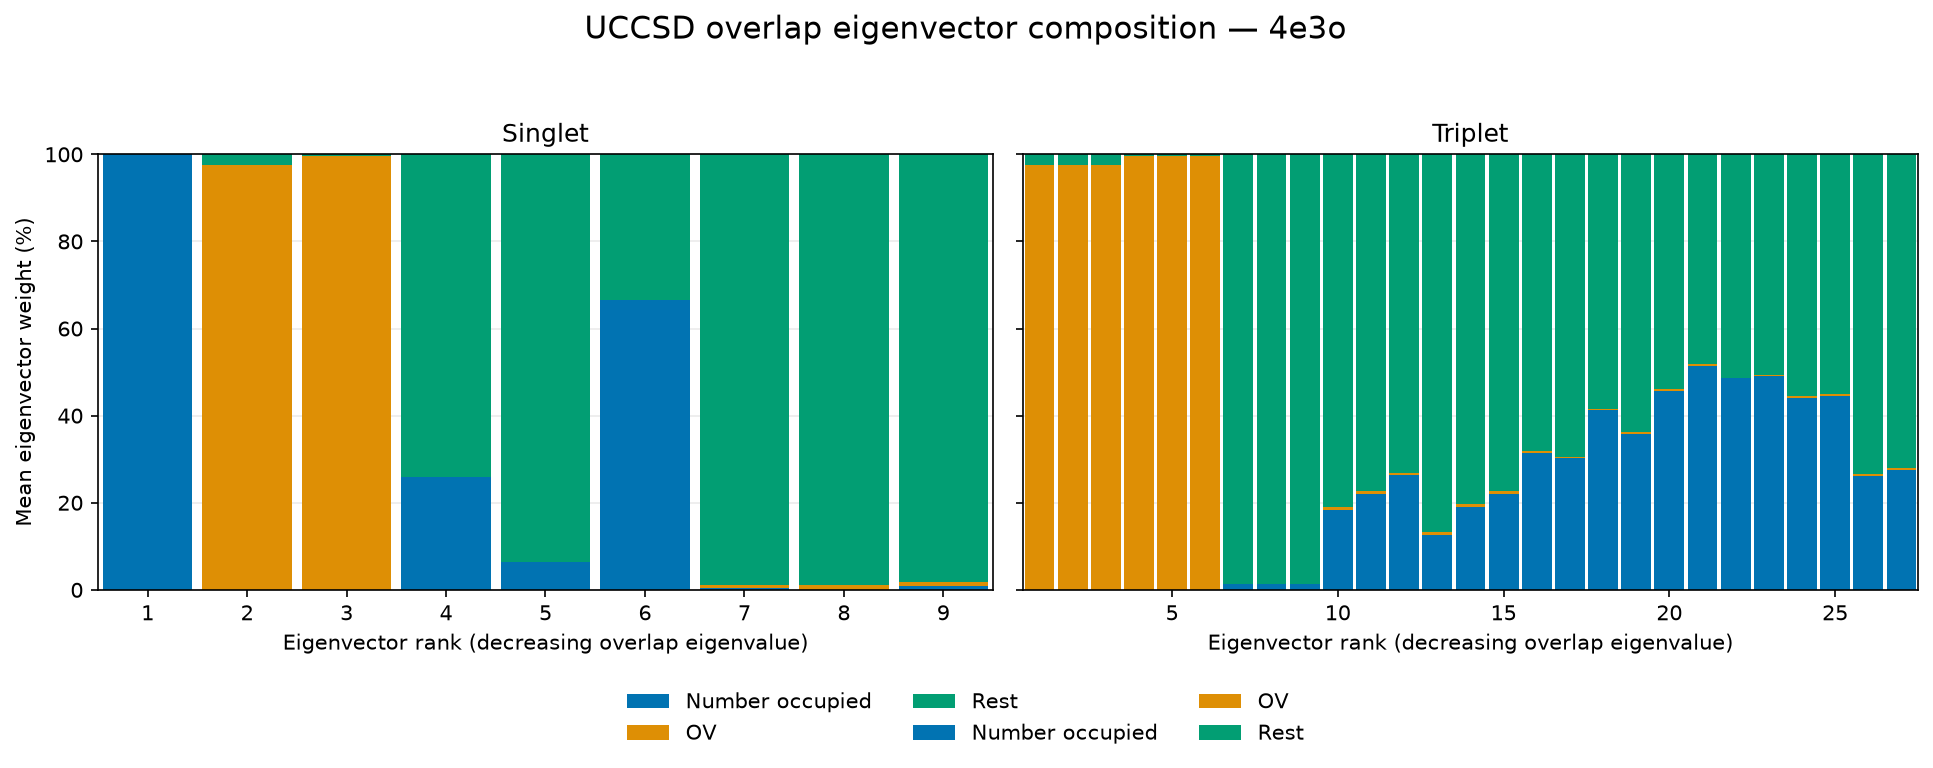
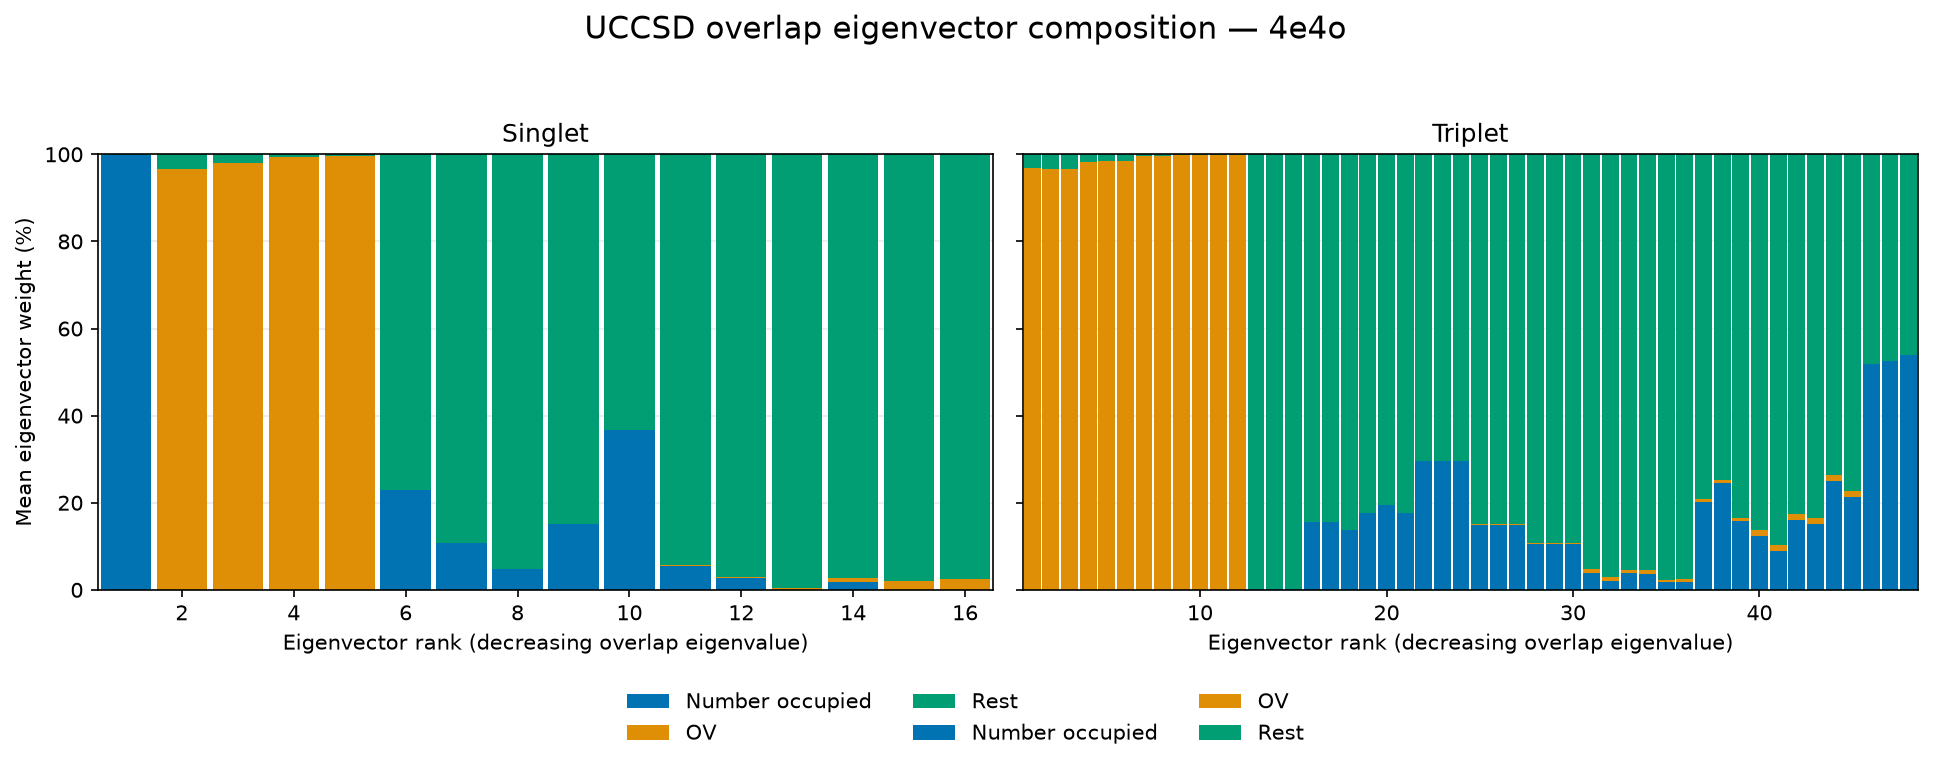
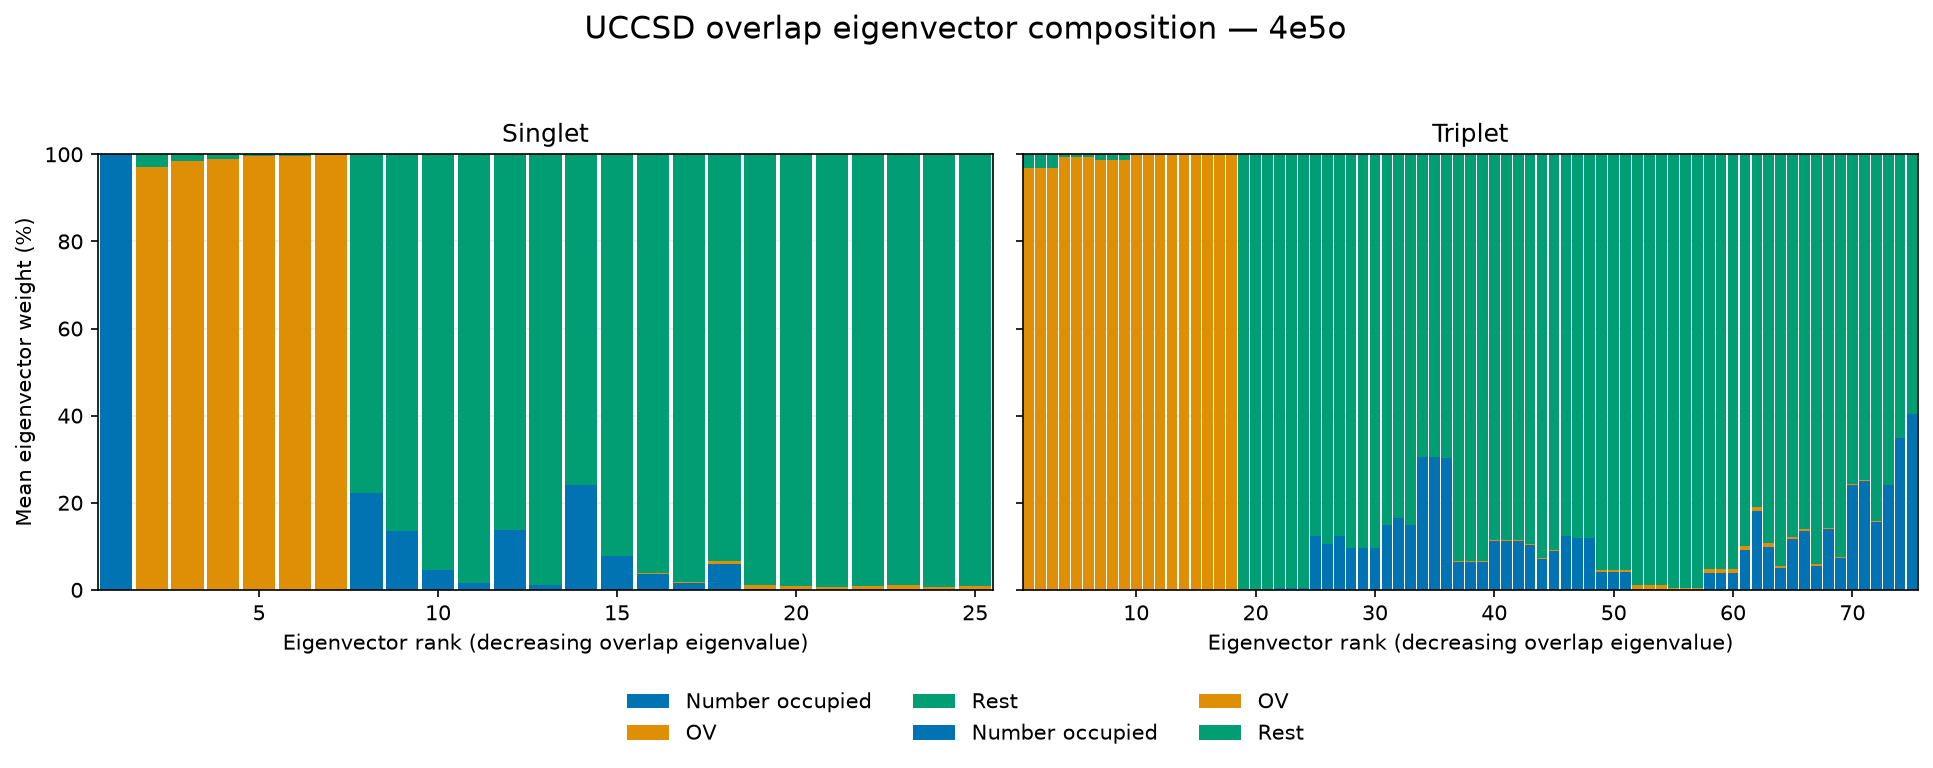
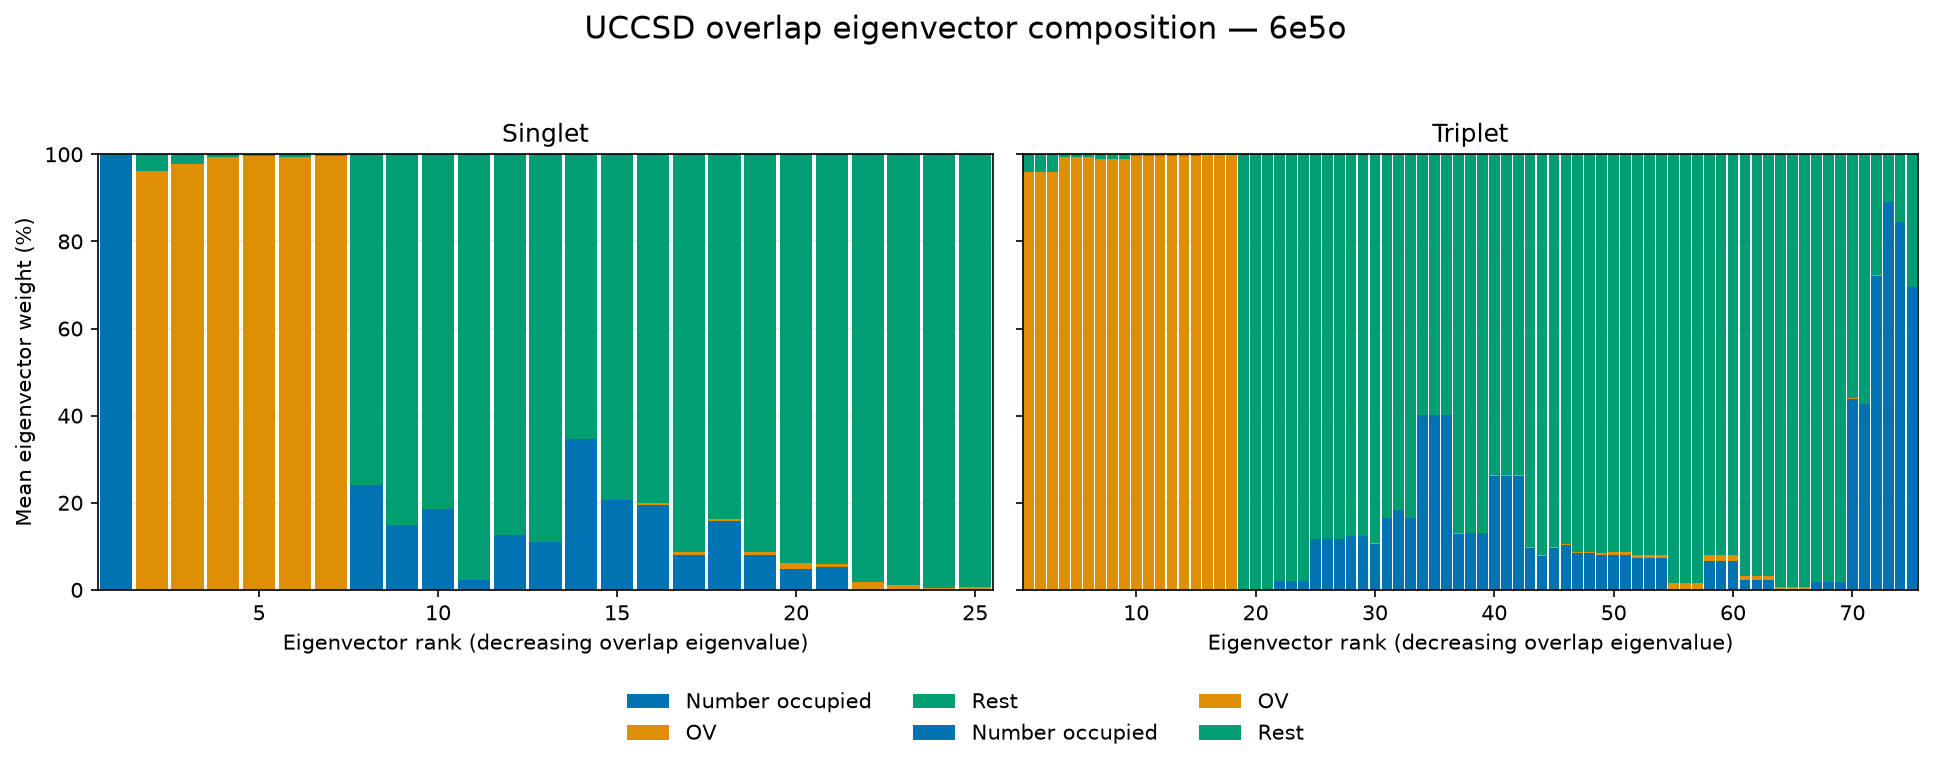
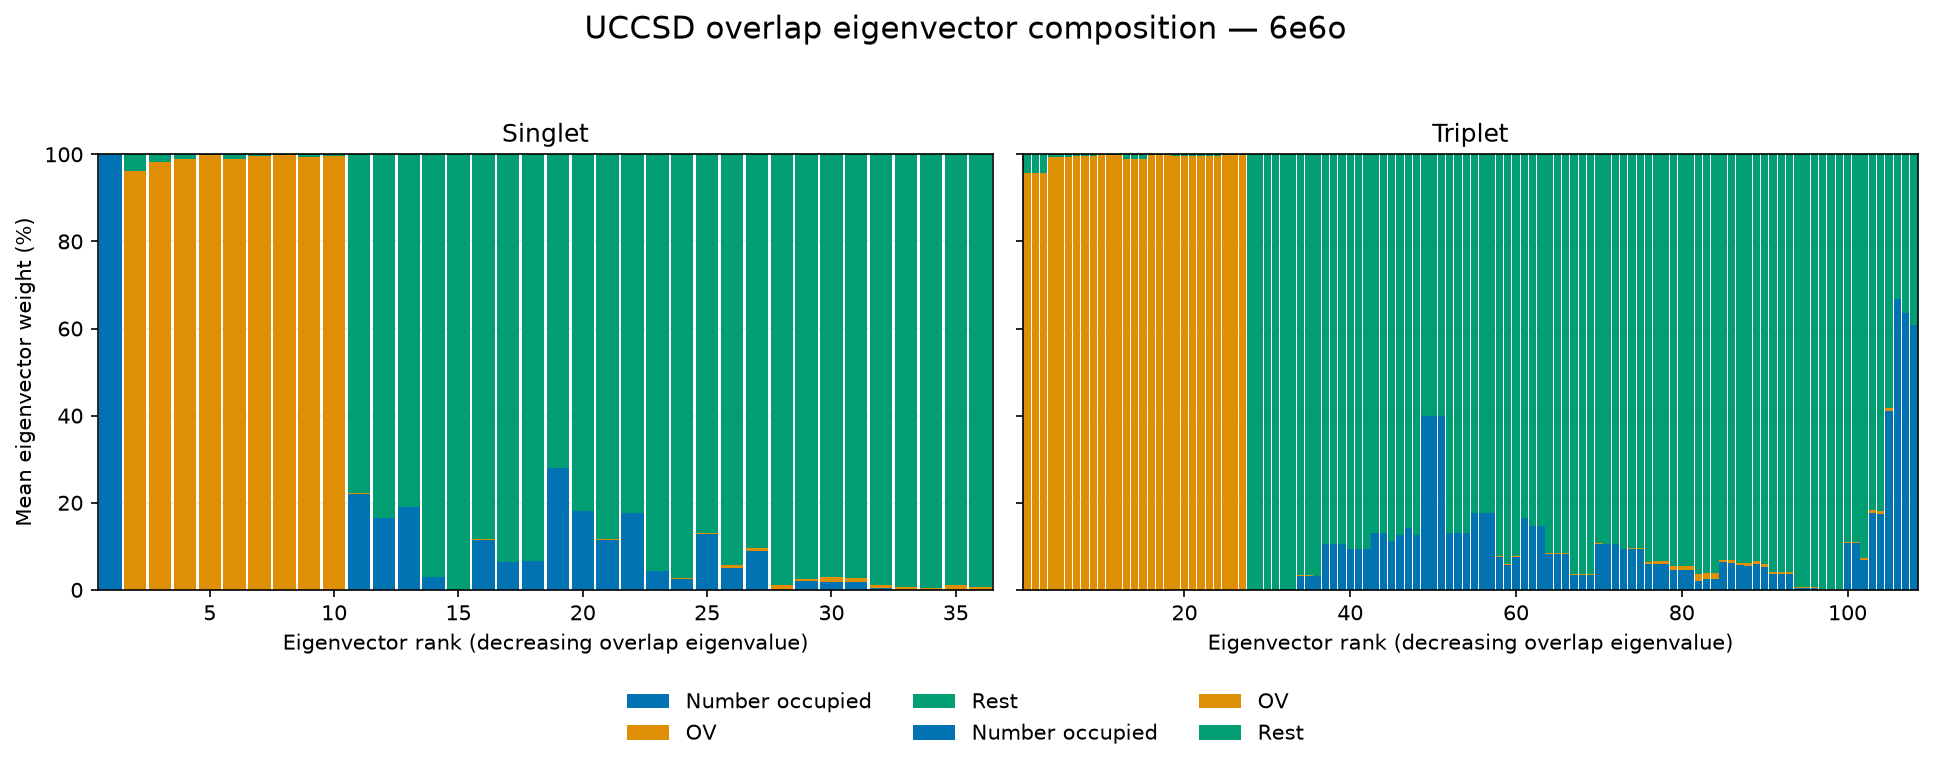

In [6]:
composition_bar_figs = []
for active_space, composition in composition_results.items():
    title = f"UCCSD overlap eigenvector composition — {active_space}"
    fig, _ = plot_eigenvector_composition_bars(composition, title=title)
    composition_bar_figs.append(fig)

print("Singlet/triplet 100%-stacked bar representation.")
show_scrollable_figs(composition_bar_figs)

## 3. Supported-Subspace Filtering

Repeat the dimension analysis after ignoring tiny overlap eigenvectors and retaining only the fully supported subspace. This section should track retained rank, discarded directions, and the effect of the filtered subspace on the QSE energies.
